Aashma Dangol
2408023

Task1

1.1 MCP Neuron for "AND" Operation

In [1]:
# Page 4 setup
def MCP_Neurons_AND(X1, X2, T):
    """
    This functions implements basic AND operations with MCP Neuron for two inputs.
    ... (Docstring omitted for brevity)
    """
    assert len(X1) == len(X2)

    ### YOUR CODE HERE ###
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = []
    for s in sums:
        if s >= T: # For AND, T=2 is typical
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    ### END YOUR CODE HERE ###

    return state_neuron

# Sample Usage for "AND" Function (Page 4)
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value for AND gate
result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


1.2 MCP Neuron for "OR" Operation

In [2]:
# Page 4/5 setup
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    ... (Docstring omitted for brevity)
    """
    assert len(X1) == len(X2)

    ### YOUR CODE HERE ###
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = []
    for s in sums:
        if s >= T: # For OR, T=1 is typical
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    ### END YOUR CODE HERE ###

    return state_neuron

# Sample Usage for "OR" Function (Page 5)
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


1.3 Section 3.2.1: Answers to Questions

Question - 1: List out all the limitations of MCP - Neurons.
Answer: MCP neurons use a fixed threshold and do not have "trainable" weights; they must be handcrafted. They can only solve linearly separable problems and are a highly simplified model of biological neurons.


Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
Answer: No, a single MCP neuron cannot solve XOR because XOR is not linearly separable. You would need a network of multiple MCP neurons (specifically, an AND gate, an OR gate, and a NOT gate combined) to solve it.

Section 2: Task 2 - Perceptron for 0 vs 1 Classification

2.1 Load and Visualize Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

file_path = "/content/drive/MyDrive/mnist_0_and_1.csv"

df_0_1 = pd.read_csv(file_path)

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

# Question 1 & 2: What does the shape of X represent?
# Answer: The shape represents (number of samples, number of features).
# Here, it is (12665 samples, 784 pixels per image).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Feature matrix shape: (12665, 784)
Label vector shape: (12665,)








1.  Q1: What does shape of X represent?
*   (n_samples, 784)
Each image has 784 pixels (28×28)
2.   Q2.What does shape of y represent?

*  (n_samples,)
Label for each image

2.2 Visualizing the Data


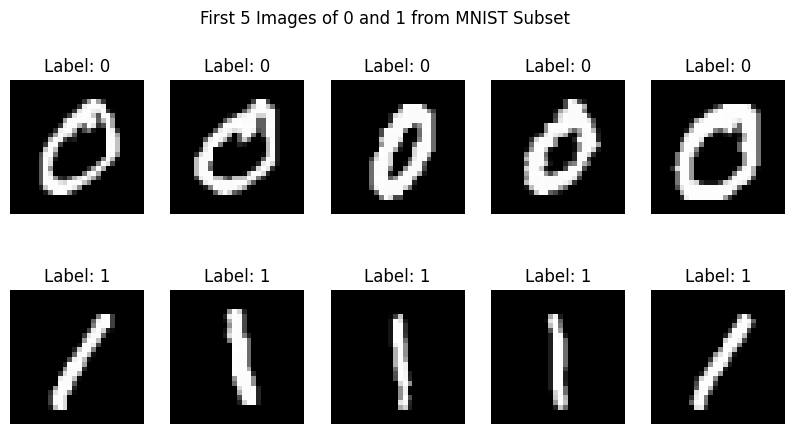

In [5]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

2.3 Initialization and Decision Function


In [6]:
# Initialization
weights = np.zeros(X.shape[1]) # 784 weights
bias = 0
learning_rate = 0.1
epochs = 10

# Answer Q3: Weights represent the importance of each pixel.
# Answer Q4: Zero initialization is a starting point; it's simple but can lead to slow initial learning.

def decision_function(X, weights, bias):
    # Compute z = sum(w*x) + b
    z = np.dot(X, weights) + bias
    # Activation function (Step function)
    return np.where(z >= 0, 1, 0)



1.   Q3: What are weights?


*   Importance of each pixel in classification


2.   Q4: Why initialize to zero?


*   Simple starting point
*   Model learns gradually




*    Might slow convergence slightly

2.4 Perceptron Training Algorithm


In [7]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        errors = 0
        for i in range(len(y)):
            # Step 1: Make prediction
            z = np.dot(X[i], weights) + bias
            y_hat = 1 if z >= 0 else 0

            # Step 2: Update if prediction is wrong
            if y_hat != y[i]:
                update = learning_rate * (y[i] - y_hat)
                weights += update * X[i]
                bias += update
                errors += 1

        accuracy = 1 - (errors / len(y))
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy

# Run Training
weights, bias, final_acc = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print(f"\nThe Final Accuracy is: {final_acc}")

Epoch 10: Accuracy = 0.9992

The Final Accuracy is: 0.9992104224240032


1.  Q5: Purpose of np.dot(X[i], weights) + bias
*  Computes weighted sum (decision boundary)

1.  Q6: When prediaction is wrong
*  Update rule:
* weights += lr * (y - y_pred) * X
* bias += lr * (y - y_pred)

1.  Q7: Why accuracy important?
* Measures model performance
* Expected: ~95%–100% for 0 vs 1

2.5 Visualize Misclassified Images


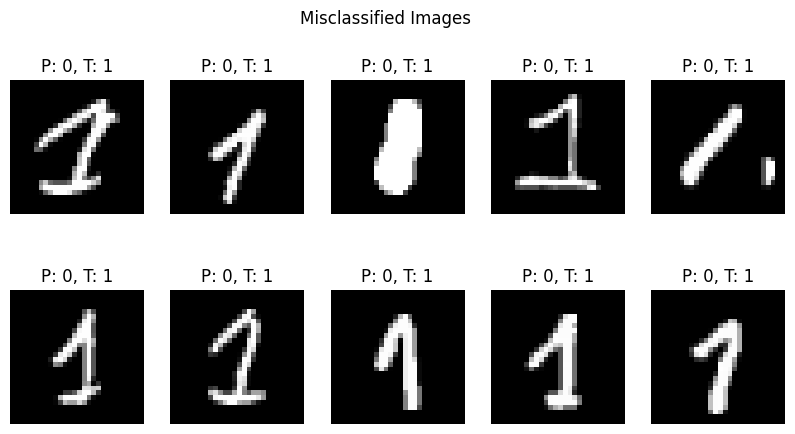

In [8]:
# Get all predictions
y_pred = decision_function(X, weights, bias)
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"P: {y_pred[idx]}, T: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

1.  Q8: misclassified_idx
* Stores indices of wrong predictions

1.  Q9: If all correct
* Model perfectly classified dataset

Section 3: Task 3 - 3 vs 5 Classification
3.1 Load and Prepare the 3 vs 5 Dataset


In [9]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

file_path = "/content/drive/MyDrive/mnist_3_and_5.csv"

df_3_5 = pd.read_csv(file_path)

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values
y_actual = df_3_5["label"].values

# IMPORTANT: The perceptron needs binary labels (0 and 1).
# We will map digit 3 to 0 and digit 5 to 1.
y_35 = np.where(y_actual == 3, 0, 1)

print("3 vs 5 Feature matrix shape:", X_35.shape)
print("Unique labels in dataset:", np.unique(y_actual))
print("Mapped labels (0 for '3', 1 for '5'):", np.unique(y_35))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
3 vs 5 Feature matrix shape: (2741, 784)
Unique labels in dataset: [3 5]
Mapped labels (0 for '3', 1 for '5'): [0 1]


3.2 Initialize and Train for 3 vs 5


In [10]:
# Re-initialize weights and bias to zero
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0
learning_rate = 0.1
epochs_35 = 50 # Let's try 50 epochs for this harder task

# Run the training
weights_35, bias_35, final_acc_35 = train_perceptron(X_35, y_35, weights_35, bias_35, learning_rate, epochs_35)

print(f"\nThe Final Accuracy for 3 vs 5 is: {final_acc_35:.4f}")

Epoch 10: Accuracy = 0.9566
Epoch 20: Accuracy = 0.9661
Epoch 30: Accuracy = 0.9726
Epoch 40: Accuracy = 0.9719
Epoch 50: Accuracy = 0.9788

The Final Accuracy for 3 vs 5 is: 0.9788


3.3 Visualize Misclassified Images (3 vs 5)


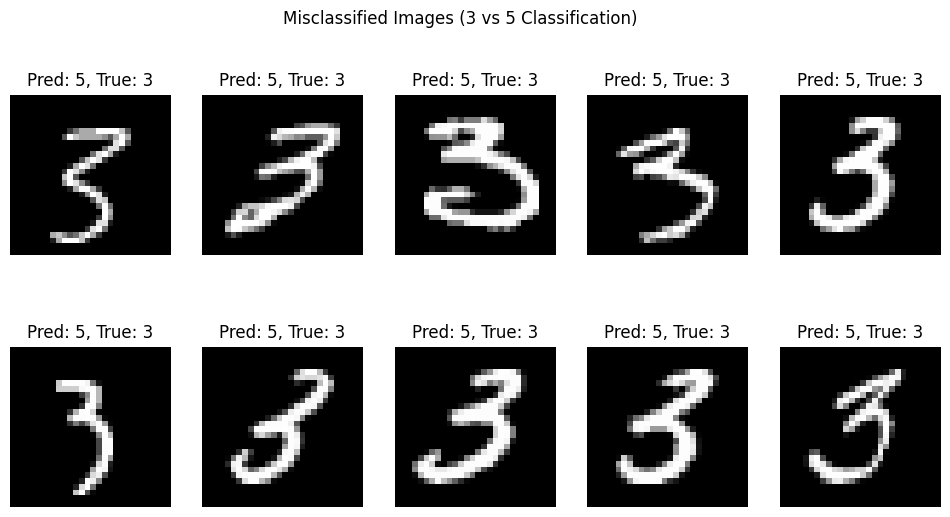

In [11]:
# Get predictions using our decision function
y_pred_35 = decision_function(X_35, weights_35, bias_35)

# Find where the prediction (0 or 1) doesn't match our mapped label (0 or 1)
mis_idx_35 = np.where(y_pred_35 != y_35)[0]

if len(mis_idx_35) > 0:
    # Use the original labels (3 and 5) for the plot titles to make it clear
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for ax, idx in zip(axes.flat, mis_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")

        # Map back for the title: 0 -> "3", 1 -> "5"
        pred_label = 3 if y_pred_35[idx] == 0 else 5
        true_label = 3 if y_35[idx] == 0 else 5

        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5 Classification)")
    plt.show()
else:
    print("All 3s and 5s were correctly classified!")

Conclusion
* The perceptron performs very well for linearly separable data like 0 vs 1, achieving high accuracy. However, for 3 vs 5 classification, accuracy decreases because the data is more complex and less linearly separable. This shows the limitation of perceptron and the need for multi-layer neural networks